# Object Detection

In [1]:
import matplotlib.pyplot as plt
from PIL import Image

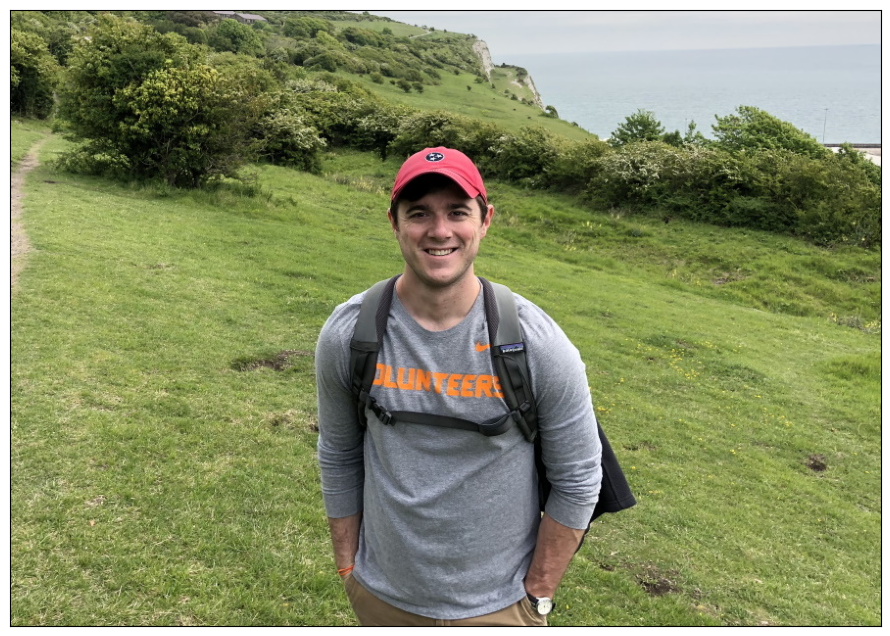

In [2]:
def show_image(path: str):
    image = Image.open(path)
    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"xticks": [], "yticks": []})
    ax.imshow(image)


show_image("Data/adam.jpg")

In [6]:
import onnxruntime as rt
from mask import *

image = Image.open("Data/adam.jpg")
image_data = preprocess(image)
session = rt.InferenceSession("Data/MaskRCNN-12-int8.onnx")
input_name = session.get_inputs()[0].name
result = session.run(None, {input_name: image_data})

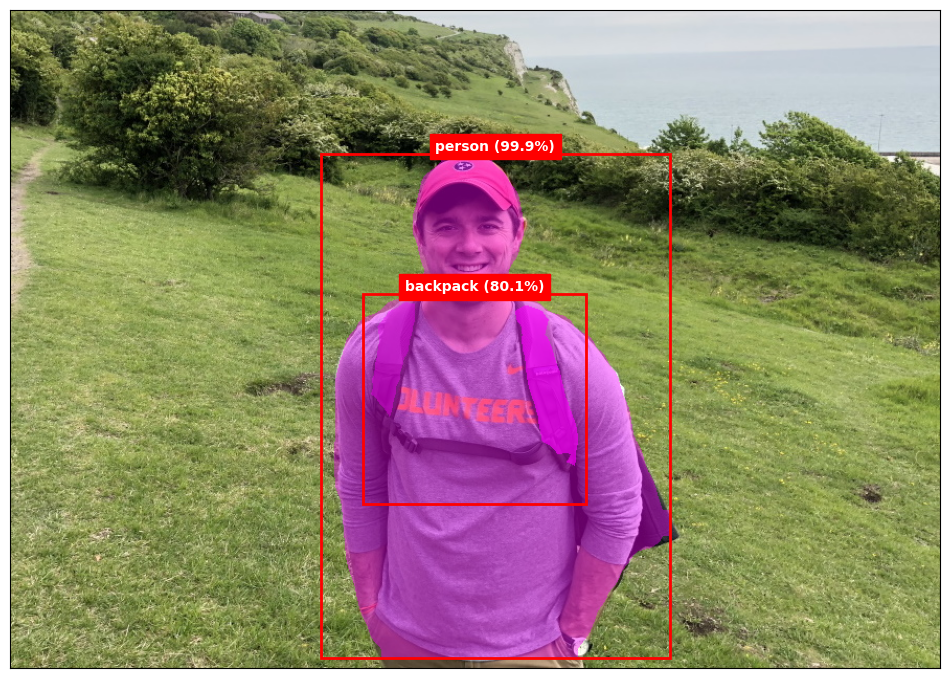

In [9]:
boxes = result[0]  # Bounding boxes
labels = result[1]  # Class labels
scores = result[2]  # Confidence scores
masks = result[3]  # Segmentation masks


annotate_image(image, boxes, labels, scores, masks)

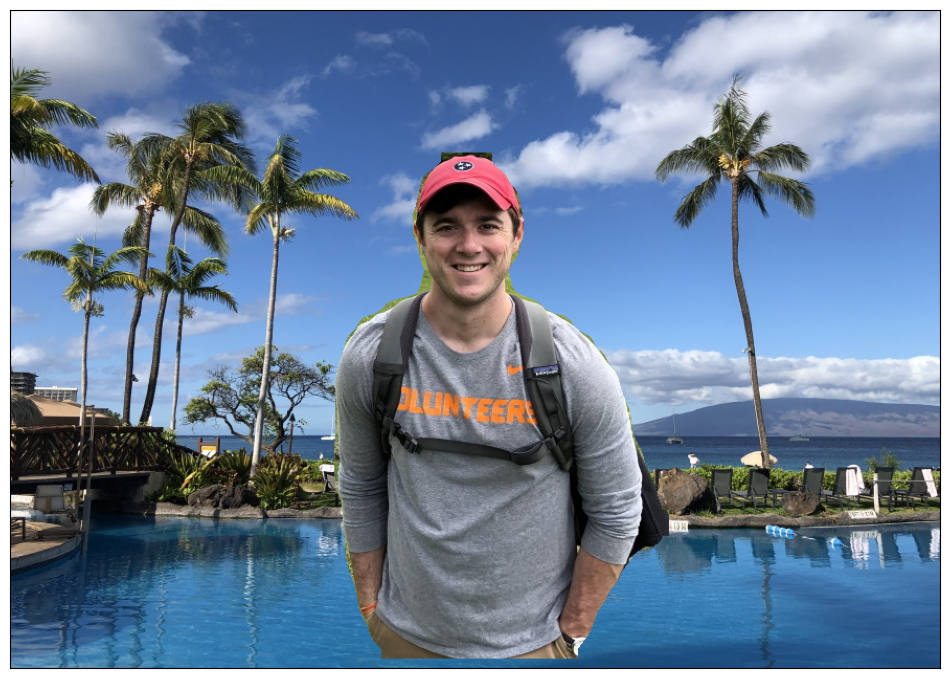

In [10]:
fg_image = Image.open("Data/adam.jpg")
bg_image = Image.open("Data/maui.jpg")

change_background(session, fg_image, bg_image)